# EgoLabel — AI-Assisted Egocentric Video Annotation

**Assessment demo:** transfer-learned action recognition + YOLOE open-vocabulary object detection, executed as two parallel branches and fused into machine-readable annotations.

### Ground-truth / leakage policy
- The 10 demonstration clips are never used for supervised action-model training or validation.
- Participants **P01, P04 and P18 are excluded entirely** from the source training pool.
- The three human-verified clips (`P01_03`, `P01_04`, `P04_19`) remain held-out evaluation/reference data.
- Source training/validation is re-split **by participant**, rather than by random clip, to prevent participant leakage.

> The official EPIC train/validation CSVs were audited before model training. See `docs/leakage_audit.csv`.


## 0. Install dependencies

Run once in a Kaggle/Ubuntu notebook. On Kaggle, PyTorch is usually already installed; the `pip` line only adds the project libraries.

Current YOLOE documentation requires a recent Ultralytics release for the YOLOE-26 family, and text prompting downloads an additional text encoder on first use. X-CLIP is available through Hugging Face Transformers and is pretrained for video recognition on Kinetics-400. 


In [1]:
# Kaggle / Linux install
#%pip -q install -U "transformers>=4.47,<6" accelerate decord av ultralytics scikit-learn pandas numpy matplotlib tqdm

%pip -q install -U "transformers>=4.47,<6" accelerate decord av ultralytics
# Optional: inspect versions
import torch, transformers, ultralytics, decord
print("Torch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Ultralytics:", ultralytics.__version__)
print("CUDA available:", torch.cuda.is_available())


Note: you may need to restart the kernel to use updated packages.
Torch: 2.10.0+cu128
Transformers: 5.17.0
Ultralytics: 8.4.164
CUDA available: True


In [2]:
# ============================================================
# FIX KAGGLE NUMPY / SCIPY / SCIKIT-LEARN ENVIRONMENT
# ============================================================

%pip install -q --force-reinstall --no-cache-dir \
    "numpy==2.0.2" \
    "scipy==1.14.1" \
    "scikit-learn==1.7.2" \
    "pandas==2.2.2"

print("Scientific Python stack repaired.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 126.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 303.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 60.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 51.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 92.9 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 41.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.1/306.1 kB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 331.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.7/506.7 kB 365.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 347.5/347.5 kB 331.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency

## 1. Configuration

**Set `SOURCE_VIDEO_ROOT` to the folder containing the EPIC-KITCHENS source videos used for transfer learning.**

Your 10 demo clips should live under `DEMO_VIDEO_ROOT` or can be placed in the same source root.

The action model uses a frozen X-CLIP backbone plus a trainable 7-class head. This is a deliberately lightweight transfer-learning demo: the expensive pretrained video representation is reused and only the classification head is trained.


In [3]:
from pathlib import Path
import os, re, json, math, random, warnings, traceback
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ============================================================
# KAGGLE INPUTS
# ============================================================
KAGGLE_INPUT = Path("/kaggle/input")

EPIC_DATASET_NAMES = [
    "datasets/ldthanh/epic-kitchens-100-p1"
    #"datasets/ldthanh/epic-kitchens-100-p2",
    #"datasets/ldthanh/epic-kitchens-100-p2-2",
    #"datasets/ldthanh/epic-kitchens-100-p3",
    #"datasets/ldthanh/epic-kitchens-100-p4",
]
EPIC_VIDEO_ROOTS = [KAGGLE_INPUT / n for n in EPIC_DATASET_NAMES
                    if (KAGGLE_INPUT / n).exists()]

def find_input_file(filename: str):
    """Robust lookup: tries the exact nested rglob pattern first (fast),
    then falls back to matching just the basename anywhere under /kaggle/input
    (works across pathlib versions and unexpected folder layouts)."""
    try:
        hits = list(KAGGLE_INPUT.rglob(filename))
        if hits:
            return hits[0]
    except Exception as e:
        print(f"[find_input_file] pattern lookup failed for {filename}: {e}")

    basename = Path(filename).name
    try:
        hits = list(KAGGLE_INPUT.rglob(basename))
        if hits:
            return hits[0]
    except Exception as e:
        print(f"[find_input_file] basename lookup failed for {basename}: {e}")
    return None

EPIC_TRAIN_CSV = find_input_file("datasets/amansandhu408/assessment/kaggle_labeller/epic_annotations/EPIC_100_train.csv")
EPIC_VAL_CSV = find_input_file("datasets/amansandhu408/assessment/kaggle_labeller/epic_annotations/EPIC_100_validation.csv")

DEMO_VIDEO_ROOT = KAGGLE_INPUT / "datasets/amansandhu408/assessment/kaggle_labeller/my_demo_video"
if not DEMO_VIDEO_ROOT.exists():
    DEMO_VIDEO_ROOT = None

# Fixed: previous path was missing a "/" ("/kaggle/inputdatasets/...") and would
# never exist, silently forcing the fallback branch every run. Go straight to
# the correct path under KAGGLE_INPUT.
HUMAN_ANN_ROOT = KAGGLE_INPUT / "datasets/amansandhu408/assessment/kaggle_labeller/human_annotations"
if not HUMAN_ANN_ROOT.exists():
    # last-resort: search for any folder named human_annotations
    hits = [p for p in KAGGLE_INPUT.rglob("human_annotations") if p.is_dir()]
    HUMAN_ANN_ROOT = hits[0] if hits else HUMAN_ANN_ROOT

# SOURCE_VIDEO_ROOT is referenced later (demo-video lookup) — define it once,
# here, instead of leaving it as an undefined name that only fails at call time.
SOURCE_VIDEO_ROOT = EPIC_VIDEO_ROOTS[0] if EPIC_VIDEO_ROOTS else KAGGLE_INPUT

print("EPIC video inputs found:", len(EPIC_VIDEO_ROOTS), "/", len(EPIC_DATASET_NAMES))
for p in EPIC_VIDEO_ROOTS:
    print("  \u2713", p)
print("EPIC train CSV:", EPIC_TRAIN_CSV)
print("EPIC validation CSV:", EPIC_VAL_CSV)
print("Demo videos:", DEMO_VIDEO_ROOT)
print("Human annotations:", HUMAN_ANN_ROOT, "(exists:", HUMAN_ANN_ROOT.exists(), ")")
print("Source video root (fallback for demo lookup):", SOURCE_VIDEO_ROOT)

# Fail loudly and early (not 40 cells later) if the CSVs genuinely aren't there.
if EPIC_TRAIN_CSV is None or EPIC_VAL_CSV is None:
    warnings.warn(
        "EPIC_TRAIN_CSV / EPIC_VAL_CSV not found under /kaggle/input. "
        "Attach the annotations dataset via 'Add Input' before running the "
        "leakage-audit / ontology cells, or the notebook will stop there."
    )

# ============================================================
# PROJECT ONTOLOGY
# ============================================================
ACTIONS = [
    "OPENS", "PICKS UP", "PUT DOWN",
    "POUR IN", "WALKS", "WASHING", "COOKING"
]
OBJECTS = ["DOOR", "FRIDGE", "BOTTLE", "GLASS", "CUP", "DRAWER"]

ACTION_TO_ID = {a: i for i, a in enumerate(ACTIONS)}
ID_TO_ACTION = {i: a for a, i in ACTION_TO_ID.items()}

OBJECT_PROMPTS = {
    "DOOR": "door",
    "FRIDGE": "refrigerator",
    "BOTTLE": "bottle",
    "GLASS": "drinking glass",
    "CUP": "cup",
    "DRAWER": "drawer",
}

DEMO_VIDEOS = [
    "P01_03", "P01_04", "P01_08", "P04_08", "P04_15",
    "P04_19", "P04_20", "P04_26", "P04_27", "P18_08"
]
HUMAN_VERIFIED_VIDEOS = ["P01_03", "P01_04", "P04_19"]
EXCLUDED_PARTICIPANTS = ["P01", "P04", "P18"]

# ============================================================
# PARAMETERS
# ============================================================
NUM_FRAMES = 8
ACTION_WINDOW_SECONDS = 2.0
ACTION_STRIDE_SECONDS = 1.0
FRAME_FPS = 4.0
BATCH_SIZE = 4
NUM_WORKERS = 0          # kept at 0: Kaggle DataLoader workers were being killed at >0
HEAD_EPOCHS = 8
HEAD_LR = 1e-3
WEIGHT_DECAY = 1e-4

# Minimum source segments a class needs (post leakage-exclusion) before we
# trust it enough to include it in training at all. Below this, later cells
# will warn loudly rather than silently training on 0-1 examples.
MIN_SEGMENTS_PER_CLASS = 20

XCLIP_MODEL_NAME = "microsoft/xclip-base-patch16"

WEIGHTS_DIR = Path("weights")
OUTPUT_DIR = Path("outputs")
CACHE_DIR = Path("cache")
FEATURE_CACHE_DIR = CACHE_DIR / "xclip_features"   # per-segment resumable cache
for d in [WEIGHTS_DIR, OUTPUT_DIR, CACHE_DIR, FEATURE_CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("DEVICE:", DEVICE)


EPIC video inputs found: 1 / 1
  ✓ /kaggle/input/datasets/ldthanh/epic-kitchens-100-p1
EPIC train CSV: /kaggle/input/datasets/amansandhu408/assessment/kaggle_labeller/epic_annotations/EPIC_100_train.csv
EPIC validation CSV: /kaggle/input/datasets/amansandhu408/assessment/kaggle_labeller/epic_annotations/EPIC_100_validation.csv
Demo videos: /kaggle/input/datasets/amansandhu408/assessment/kaggle_labeller/my_demo_video
Human annotations: /kaggle/input/datasets/amansandhu408/assessment/kaggle_labeller/human_annotations (exists: True )
Source video root (fallback for demo lookup): /kaggle/input/datasets/ldthanh/epic-kitchens-100-p1
DEVICE: cuda


## 2. Leakage audit — run this before training

The audit checks the exact 10 demonstration video IDs against the supplied EPIC-KITCHENS train and validation annotations.

**Expected result from the supplied CSVs:** all 10 appear in either official train or official validation, so using those rows unchanged would leak the demo set. The code therefore excludes **P01/P04/P18 entirely** from the source model pool.


In [4]:
# Load supplied source annotations (fail with a clear message instead of a
# bare FileNotFoundError deep inside pandas if the CSVs weren't attached).
if EPIC_TRAIN_CSV is None or EPIC_VAL_CSV is None:
    raise FileNotFoundError(
        "EPIC_100_train.csv / EPIC_100_validation.csv were not found under "
        "/kaggle/input. Attach the annotations dataset (Add Input) and "
        "re-run from cell 5 (Configuration)."
    )

epic_train = pd.read_csv(EPIC_TRAIN_CSV)
epic_val = pd.read_csv(EPIC_VAL_CSV)
source_all = pd.concat(
    [epic_train.assign(source_split="official_train"),
     epic_val.assign(source_split="official_validation")],
    ignore_index=True
)

audit_rows = []
for video_id in DEMO_VIDEOS:
    participant = video_id.split("_")[0]
    tr_n = int((epic_train.video_id == video_id).sum())
    va_n = int((epic_val.video_id == video_id).sum())
    audit_rows.append({
        "video_id": video_id,
        "participant": participant,
        "human_verified": video_id in HUMAN_VERIFIED_VIDEOS,
        "official_train_rows": tr_n,
        "official_validation_rows": va_n,
        "found_in_source_splits": (tr_n + va_n) > 0,
        "excluded_from_training": participant in EXCLUDED_PARTICIPANTS,
    })

leakage_audit = pd.DataFrame(audit_rows)
display(leakage_audit)

assert leakage_audit["excluded_from_training"].all(), (
    "Leakage guard failed: every demo participant must be excluded."
)
leakage_audit.to_csv(OUTPUT_DIR / "leakage_audit.csv", index=False)


,video_id,participant,human_verified,official_train_rows,official_validation_rows,found_in_source_splits,excluded_from_training
0,P01_03,P01,True,42,0,True,True
1,P01_04,P01,True,32,0,True,True
2,P01_08,P01,False,32,0,True,True
3,P04_08,P04,False,20,0,True,True
4,P04_15,P04,False,1,0,True,True
5,P04_19,P04,True,5,0,True,True
6,P04_20,P04,False,13,0,True,True
7,P04_26,P04,False,0,3,True,True
8,P04_27,P04,False,0,11,True,True
9,P18_08,P18,False,0,19,True,True


## 3. Build the custom 7-class action ontology

The source EPIC-KITCHENS `verb` field contains fine-grained instances such as `pick-up`, `put-down`, `pour-into`, `walk`, `rinse`, `fry`, etc.

For this assessment, we map them into your seven canonical action labels. The mapping is intentionally explicit and lives in code so a reviewer can audit exactly how source labels became project labels.

`WALKS`, `COOKING` and `POUR IN` are sparse after leakage exclusion; the notebook reports those counts rather than hiding them.


In [5]:
VERB_MAP = {
    "OPENS": {"open", "open-up", "open-on", "open-to", "open-with"},
    "PICKS UP": {"pick-up", "pick", "grab", "grab-up", "grab-down", "take", "get", "get-from"},
    "PUT DOWN": {"put-down", "set-down", "place-down", "lay-down", "put", "place"},
    "POUR IN": {"pour-in", "pour-into", "tip-into", "drizzle-into", "pour-inside", "shake-into"},
    "WALKS": {"walk", "walk-around", "walk-into", "walk-with"},
    "WASHING": {"wash", "rinse", "clean", "wipe", "sponge", "lather", "soap"},
    "COOKING": {"cook", "cook-into", "fry", "fry-in", "stir-fry", "boil", "boil-with", "heat", "steam", "toast"},
}

required_cols = {"participant_id", "verb"}
missing_cols = required_cols - set(source_all.columns)
if missing_cols:
    raise KeyError(
        f"Expected columns {sorted(required_cols)} in the EPIC CSVs, "
        f"missing: {sorted(missing_cols)}. Columns found: {list(source_all.columns)}"
    )

source_pool = source_all[
    ~source_all["participant_id"].isin(EXCLUDED_PARTICIPANTS)
].copy()

source_pool["custom_action"] = None
for label, verbs in VERB_MAP.items():
    m = source_pool["verb"].fillna("").astype(str).str.lower().isin(verbs)
    source_pool.loc[m, "custom_action"] = label

source_pool = source_pool[source_pool["custom_action"].notna()].copy()

class_counts = (
    source_pool["custom_action"]
    .value_counts()
    .reindex(ACTIONS, fill_value=0)
    .rename_axis("action")
    .reset_index(name="segments")
)
display(class_counts)
class_counts.to_csv(OUTPUT_DIR / "source_action_class_counts.csv", index=False)

# Classes below MIN_SEGMENTS_PER_CLASS are flagged, not silently dropped:
# training still runs (few-shot on those classes), but the low-coverage list
# is surfaced now, saved to disk, and reused later (README / evaluation notes)
# instead of being discovered only after a confusing training run.
LOW_COVERAGE_ACTIONS = class_counts.loc[
    class_counts["segments"] < MIN_SEGMENTS_PER_CLASS, "action"
].tolist()
ZERO_COVERAGE_ACTIONS = class_counts.loc[class_counts["segments"] == 0, "action"].tolist()

for row in class_counts.itertuples():
    if row.segments < MIN_SEGMENTS_PER_CLASS:
        warnings.warn(
            f"{row.action}: only {row.segments} source segments after leakage "
            "exclusion. Treat this class as a pilot/few-shot result, not a "
            "production benchmark."
        )

if ZERO_COVERAGE_ACTIONS:
    warnings.warn(
        f"{ZERO_COVERAGE_ACTIONS} have ZERO usable source segments with the "
        "currently attached EPIC parts (e.g. only epic-kitchens-100-p1). "
        "The action head cannot learn these classes at all until additional "
        "EPIC parts are attached in cell 5 (EPIC_DATASET_NAMES). Training "
        "will proceed on the remaining classes, but expect 0 recall on these."
    )

json.dumps({"low_coverage": LOW_COVERAGE_ACTIONS, "zero_coverage": ZERO_COVERAGE_ACTIONS})
Path(OUTPUT_DIR / "class_coverage_flags.json").write_text(
    json.dumps({"low_coverage": LOW_COVERAGE_ACTIONS, "zero_coverage": ZERO_COVERAGE_ACTIONS}, indent=2)
)


,action,segments
0,OPENS,4626
1,PICKS UP,13316
2,PUT DOWN,9629
3,POUR IN,571
4,WALKS,8
5,WASHING,6810
6,COOKING,83


/tmp/ipykernel_197/2373074638.py:51: UserWarning: WALKS: only 8 source segments after leakage exclusion. Treat this class as a pilot/few-shot result, not a production benchmark.
  warnings.warn(


62

## 4. Index source videos across the attached Kaggle datasets

Attach the five public EPIC-KITCHENS video-part datasets through **Add Input**.
They are accessed read-only under `/kaggle/input`; do not copy the full corpus into
`/kaggle/working`.

The notebook scans file metadata and only decodes the selected training segments
during X-CLIP feature extraction.


In [6]:
# Multi-root indexer for the attached Kaggle datasets.
# This scans filenames/metadata only; it does NOT decode video bytes.
VIDEO_EXTS = {".mp4", ".MP4", ".mov", ".MOV", ".mkv", ".MKV"}

def build_video_index(roots):
    index = {}
    for root in roots:
        print(f"Scanning: {root}")
        found = 0
        if not root.exists():
            print("  (root does not exist, skipping)")
            continue
        try:
            for p in root.rglob("*"):
                try:
                    if p.is_file() and p.suffix in VIDEO_EXTS:
                        index.setdefault(p.stem, str(p))
                        found += 1
                except OSError as e:
                    # e.g. broken symlink / permission issue on one entry;
                    # don't let one bad path abort the whole scan
                    print(f"  [skip entry] {p}: {e}")
                    continue
        except Exception as e:
            print(f"  [skip root] {root}: {e}")
        print(f"  video files found: {found}")
    return index

video_index = build_video_index(EPIC_VIDEO_ROOTS)
print("Unique source video IDs:", len(video_index))

if len(video_index) == 0:
    warnings.warn(
        "No source video files were found under EPIC_VIDEO_ROOTS. All "
        "segments will be dropped as 'missing physical video' below. "
        "Check that the EPIC video dataset is attached as a Kaggle input."
    )

source_pool["video_path"] = source_pool["video_id"].map(video_index)
missing = source_pool["video_path"].isna()

print("Mapped segments:", int((~missing).sum()))
print("Segments with missing physical video:", int(missing.sum()))

if missing.any():
    print(
        "Examples of missing videos:",
        source_pool.loc[missing, "video_id"].head(20).tolist()
    )

# IMPORTANT: remove segments whose physical video is unavailable
source_pool = source_pool.loc[~missing].copy().reset_index(drop=True)

if len(source_pool) == 0:
    raise RuntimeError(
        "No source segments with accessible videos were found. Check that "
        "the correct EPIC-KITCHENS video dataset(s) are attached (Add Input) "
        "and that EPIC_DATASET_NAMES in cell 5 matches the attached dataset "
        "slug(s)."
    )

# Final safety check
assert source_pool["video_path"].notna().all()
assert source_pool["video_path"].map(lambda p: Path(p).exists()).all()

print("Final usable segments:", len(source_pool))

# Re-check class coverage now that we've also dropped segments with no
# physical video file — the counts from cell 9 were verb-mapping-only and
# can be optimistic relative to what's actually usable.
usable_counts = (
    source_pool["custom_action"].value_counts().reindex(ACTIONS, fill_value=0)
)
print("\nUsable (video-backed) segment counts per class:")
print(usable_counts)
for action, n in usable_counts.items():
    if n < MIN_SEGMENTS_PER_CLASS:
        warnings.warn(f"{action}: only {n} usable video-backed segments.")


Scanning: /kaggle/input/datasets/ldthanh/epic-kitchens-100-p1
  video files found: 79
Unique source video IDs: 79
Mapped segments: 5201
Segments with missing physical video: 29842
Examples of missing videos: ['P02_01', 'P02_01', 'P02_01', 'P02_01', 'P02_01', 'P02_01', 'P02_01', 'P02_01', 'P02_01', 'P02_01', 'P02_01', 'P02_01', 'P02_01', 'P02_01', 'P02_01', 'P02_01', 'P02_01', 'P02_01', 'P02_01', 'P02_01']
Final usable segments: 5201

Usable (video-backed) segment counts per class:
custom_action
OPENS        449
PICKS UP    1629
PUT DOWN    1810
POUR IN        2
WALKS          0
WASHING     1310
COOKING        1
Name: count, dtype: int64


/tmp/ipykernel_197/3007618301.py:78: UserWarning: POUR IN: only 2 usable video-backed segments.
  warnings.warn(f"{action}: only {n} usable video-backed segments.")
/tmp/ipykernel_197/3007618301.py:78: UserWarning: WALKS: only 0 usable video-backed segments.
  warnings.warn(f"{action}: only {n} usable video-backed segments.")
/tmp/ipykernel_197/3007618301.py:78: UserWarning: COOKING: only 1 usable video-backed segments.
  warnings.warn(f"{action}: only {n} usable video-backed segments.")


## 5. Participant-disjoint train/validation split

We do **not** use the official EPIC train/validation boundary as our experimental validation boundary. Instead, after excluding P01/P04/P18, we create our own participant-grouped split.

This prevents the same participant from appearing in both training and validation.


In [7]:
def grouped_split_with_label_coverage(df, group_col="participant_id", label_col="custom_action",
                                      val_fraction=0.20, seed=42, max_tries=100):
    labels = set(ACTIONS)
    n_groups = df[group_col].nunique()
    if n_groups < 2:
        warnings.warn(
            f"Only {n_groups} participant(s) available after leakage exclusion "
            "and video-availability filtering. A participant-disjoint split "
            "needs at least 2 groups; falling back to a random (non-grouped) "
            "split. Attach more EPIC parts in cell 5 for a proper split."
        )
        from sklearn.model_selection import train_test_split
        tr, va = train_test_split(df, test_size=val_fraction, random_state=seed,
                                   stratify=df[label_col] if df[label_col].nunique() > 1 else None)
        return tr.copy(), va.copy(), seed

    for s in range(seed, seed + max_tries):
        splitter = GroupShuffleSplit(n_splits=1, test_size=val_fraction, random_state=s)
        tr_idx, va_idx = next(splitter.split(df, groups=df[group_col]))
        tr = df.iloc[tr_idx].copy()
        va = df.iloc[va_idx].copy()
        if set(tr[label_col]) == labels and set(va[label_col]) == labels:
            return tr, va, s
    # Fall back to the first split if rare classes prevent perfect coverage.
    warnings.warn(
        f"Could not find a participant-disjoint split with full class coverage "
        f"in {max_tries} tries (expected given how sparse WALKS/COOKING are). "
        "Using the first split; some classes may be entirely absent from "
        "train or val — check the per-split counts printed below."
    )
    splitter = GroupShuffleSplit(n_splits=1, test_size=val_fraction, random_state=seed)
    tr_idx, va_idx = next(splitter.split(df, groups=df[group_col]))
    return df.iloc[tr_idx].copy(), df.iloc[va_idx].copy(), seed

train_segments, val_segments, used_seed = grouped_split_with_label_coverage(source_pool)

assert len(train_segments) > 0, "Train split is empty."
assert len(val_segments) > 0, "Validation split is empty."

print("Group-split seed:", used_seed)
print("Train participants:", train_segments.participant_id.nunique())
print("Val participants:", val_segments.participant_id.nunique())
print("Participant overlap:",
      len(set(train_segments.participant_id) & set(val_segments.participant_id)))

assert set(train_segments.participant_id).isdisjoint(set(val_segments.participant_id))

for name, df in [("train", train_segments), ("val", val_segments)]:
    counts = df.custom_action.value_counts().reindex(ACTIONS, fill_value=0)
    print(f"\n{name} counts:")
    print(counts)

train_segments.to_csv(OUTPUT_DIR / "train_segments.csv", index=False)
val_segments.to_csv(OUTPUT_DIR / "val_segments.csv", index=False)


Group-split seed: 42
Train participants: 1
Val participants: 1
Participant overlap: 0

train counts:
custom_action
OPENS        328
PICKS UP     956
PUT DOWN    1110
POUR IN        2
WALKS          0
WASHING      819
COOKING        1
Name: count, dtype: int64

val counts:
custom_action
OPENS       121
PICKS UP    673
PUT DOWN    700
POUR IN       0
WALKS         0
WASHING     491
COOKING       0
Name: count, dtype: int64


/tmp/ipykernel_197/683264588.py:25: UserWarning: Could not find a participant-disjoint split with full class coverage in 100 tries (expected given how sparse WALKS/COOKING are). Using the first split; some classes may be entirely absent from train or val — check the per-split counts printed below.
  warnings.warn(


## 6. Limit the pilot size without changing the participant split

X-CLIP is a large video model. This demo intentionally caps the number of training/validation segments per class so the notebook remains practical on a single GPU.

For rare classes, all available examples are retained. We use class-weighted cross entropy rather than creating thousands of duplicate copies of a tiny class.


In [8]:
MAX_TRAIN_PER_CLASS = 40
MAX_VAL_PER_CLASS = 15

def cap_per_class(df, label_col="custom_action", max_per_class=500, seed=42):
    parts = []
    for label in ACTIONS:
        sub = df[df[label_col] == label]
        if len(sub) == 0:
            continue  # nothing to cap/keep for this class in this split
        if len(sub) > max_per_class:
            sub = sub.sample(max_per_class, random_state=seed)
        parts.append(sub)
    if not parts:
        raise RuntimeError(
            "cap_per_class produced an empty dataframe — every class had 0 "
            "rows in this split. Check the counts printed in the previous cell."
        )
    out = pd.concat(parts, ignore_index=True)
    return out.sample(frac=1.0, random_state=seed).reset_index(drop=True)

train_segments = cap_per_class(train_segments, max_per_class=MAX_TRAIN_PER_CLASS, seed=SEED)
val_segments = cap_per_class(val_segments, max_per_class=MAX_VAL_PER_CLASS, seed=SEED)

assert len(train_segments) > 0 and len(val_segments) > 0

print("Pilot train size:", len(train_segments))
print("Pilot validation size:", len(val_segments))
print("Pilot train class counts:")
print(train_segments.custom_action.value_counts().reindex(ACTIONS, fill_value=0))
print("Pilot val class counts:")
print(val_segments.custom_action.value_counts().reindex(ACTIONS, fill_value=0))


Pilot train size: 163
Pilot validation size: 60
Pilot train class counts:
custom_action
OPENS       40
PICKS UP    40
PUT DOWN    40
POUR IN      2
WALKS        0
WASHING     40
COOKING      1
Name: count, dtype: int64
Pilot val class counts:
custom_action
OPENS       15
PICKS UP    15
PUT DOWN    15
POUR IN      0
WALKS        0
WASHING     15
COOKING      0
Name: count, dtype: int64


## 7. Video frame loading

We sample frames with `decord`, because random access is substantially more convenient for temporal segments than repeatedly decoding whole videos.

For the action model:
- 8 frames per sample
- 224×224 through the X-CLIP processor

For the automation demo:
- 4 sampled frames/second
- 2-second action windows
- 1-second window stride

The same sampled frame cache is reused by both the action and object branches.


In [9]:
from decord import VideoReader, cpu

def read_video_segment(video_path, start_sec, end_sec, num_frames=NUM_FRAMES):
    """Decode num_frames frames from [start_sec, end_sec] of video_path.
    Raises on genuine problems (caller decides whether to skip/retry) but
    never leaves indices out of range and never silently returns garbage."""

    if pd.isna(video_path):
        raise ValueError("video_path is NaN")

    video_path = Path(video_path)

    if not video_path.exists():
        raise FileNotFoundError(f"Video not found: {video_path}")

    # A fresh VideoReader per call (no lru_cache): caching open file handles
    # across a long resumable extraction run is what produced the earlier
    # DataLoader worker crashes when Kaggle recycled/killed workers holding
    # stale handles. num_threads=1 keeps this stable with NUM_WORKERS=0.
    vr = VideoReader(str(video_path), ctx=cpu(0), num_threads=1)

    total = len(vr)
    if total <= 0:
        raise ValueError(f"Empty video (0 frames): {video_path}")

    fps = float(vr.get_avg_fps()) or 30.0
    duration = total / fps

    def to_seconds(t):
        if pd.isna(t):
            return 0.0
        if isinstance(t, (int, float, np.integer, np.floating)):
            return float(t)
        if isinstance(t, str) and ":" in t:
            return pd.to_timedelta(t).total_seconds()
        return float(t)

    start_sec = max(0.0, to_seconds(start_sec))
    end_sec = min(to_seconds(end_sec), duration)

    if end_sec < start_sec:
        start_sec, end_sec = end_sec, start_sec

    start_idx = max(0, min(total - 1, int(round(start_sec * fps))))
    end_idx = max(start_idx, min(total - 1, int(round(end_sec * fps))))

    indices = np.linspace(start_idx, end_idx, num=num_frames, dtype=np.int64)
    indices = np.clip(indices, 0, total - 1)

    frames = vr.get_batch(indices).asnumpy()
    if frames.shape[0] != num_frames:
        raise ValueError(
            f"Decoded {frames.shape[0]} frames, expected {num_frames}: {video_path}"
        )

    timestamps = indices / fps
    return frames, timestamps


# Quick smoke test on one training segment — wrapped so a single corrupt
# source file doesn't stop the whole notebook run at this early stage.
try:
    assert len(train_segments) > 0, "Training segments are empty."
    sample_row = train_segments.iloc[0]
    frames, ts = read_video_segment(
        sample_row.video_path,
        sample_row.start_timestamp,
        sample_row.stop_timestamp,
        NUM_FRAMES
    )
    print("Smoke test OK -", sample_row.video_id, sample_row.custom_action)
    print("Frames shape:", frames.shape, "| timestamps:", ts)
except Exception as e:
    print(f"[smoke test] read_video_segment failed on the first sample row: {e}")
    print("Extraction in the next cell still runs per-segment and will skip "
          "any further bad rows rather than crash.")


Smoke test OK - P22_07 WASHING
Frames shape: (8, 1080, 1920, 3) | timestamps: [     2132.3      2132.9      2133.4        2134      2134.5      2135.1      2135.6      2136.2]


## 8. X-CLIP pretrained backbone

X-CLIP is used as a pretrained video representation. The official Hugging Face implementation exposes `get_video_features()` and expects a temporal batch of video frames. The base checkpoint is pretrained on Kinetics-400 and is intended for zero-shot/few-shot/supervised video recognition.

We freeze this backbone for the first demo and train a small classification head on top.


In [10]:
from transformers import AutoProcessor, AutoModel

processor = AutoProcessor.from_pretrained(XCLIP_MODEL_NAME)
xclip = AutoModel.from_pretrained(XCLIP_MODEL_NAME)
xclip = xclip.to(DEVICE).eval()

for p in xclip.parameters():
    p.requires_grad = False

print("Loaded:", XCLIP_MODEL_NAME)


Loading weights:   0%|          | 0/591 [00:00<?, ?it/s]

Loaded: microsoft/xclip-base-patch16


## 9. Dataset + feature extraction

We cache X-CLIP features to disk so training the classification head does **not** repeatedly run the 0.2B-parameter backbone.

This is the key efficiency trick for the take-home demo:
1. Decode each segment once.
2. Run frozen X-CLIP once.
3. Cache the feature vector.
4. Train the tiny classifier quickly.


In [11]:
# ============================================================
# FAST + RESUMABLE X-CLIP FEATURE EXTRACTION
# ============================================================

def timestamp_to_seconds(t):
    """Convert EPIC timestamp formats safely to seconds."""
    if pd.isna(t):
        return 0.0

    if isinstance(t, (int, float, np.integer, np.floating)):
        return float(t)

    if isinstance(t, str):
        t = t.strip()

        # HH:MM:SS.xx
        if ":" in t:
            return pd.to_timedelta(t).total_seconds()

        return float(t)

    return float(t)


def _feature_path(split_name, row_idx):
    return FEATURE_CACHE_DIR / f"{split_name}_{row_idx:06d}.pt"


@torch.inference_mode()
def extract_features_resumable(
    df,
    split_name,
    processor,
    batch_size=BATCH_SIZE
):
    df = df.reset_index(drop=True)

    todo_idx = [
        i for i in range(len(df))
        if not _feature_path(split_name, i).exists()
    ]

    print(
        f"[{split_name}] "
        f"{len(df)-len(todo_idx)}/{len(df)} already cached, "
        f"{len(todo_idx)} remaining."
    )

    failures = []

    pbar = tqdm(
        total=len(todo_idx),
        desc=f"X-CLIP [{split_name}]"
    )

    i = 0

    while i < len(todo_idx):

        batch_positions = todo_idx[i:i + batch_size]
        batch_rows = []
        batch_frames = []

        # ----------------------------------------------------
        # Decode batch
        # ----------------------------------------------------
        for pos in batch_positions:

            row = df.iloc[pos]

            try:
                frames, _ = read_video_segment(
                    row.video_path,
                    row.start_timestamp,
                    row.stop_timestamp,
                    NUM_FRAMES
                )

                batch_rows.append((pos, row))
                batch_frames.append(frames)

            except Exception as e:

                failures.append({
                    "split": split_name,
                    "row": pos,
                    "video_id": getattr(row, "video_id", "?"),
                    "error": f"decode: {e}"
                })

                pbar.update(1)

        if not batch_rows:
            i += batch_size
            continue

        # ----------------------------------------------------
        # X-CLIP batch inference
        # ----------------------------------------------------
        try:

            inputs = processor(
                videos=[list(f) for f in batch_frames],
                return_tensors="pt"
            )

            pixel_values = inputs["pixel_values"].to(
                DEVICE,
                non_blocking=True
            )

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16,
                enabled=(DEVICE == "cuda")
            ):

                out = xclip.get_video_features(
                    pixel_values=pixel_values
                )

            feats = (
                out.pooler_output
                if hasattr(out, "pooler_output")
                else out[1]
            ).float().cpu()

            # ------------------------------------------------
            # SAVE IMMEDIATELY
            # ------------------------------------------------
            for (pos, row), feat in zip(batch_rows, feats):

                label = ACTION_TO_ID[row.custom_action]

                start_sec = timestamp_to_seconds(
                    row.start_timestamp
                )

                stop_sec = timestamp_to_seconds(
                    row.stop_timestamp
                )

                torch.save(
                    {
                        "feature": feat,
                        "label": label,
                        "video_id": row.video_id,
                        "participant_id": row.participant_id,
                        "start": start_sec,
                        "stop": stop_sec,
                        "custom_action": row.custom_action,
                    },
                    _feature_path(split_name, pos)
                )

            pbar.update(len(batch_rows))

        # ----------------------------------------------------
        # ONLY use fallback for actual X-CLIP failures
        # ----------------------------------------------------
        except Exception as batch_error:

            print(
                f"\n[{split_name}] "
                f"batch failed: {batch_error}"
            )

            torch.cuda.empty_cache()

            for pos, row in batch_rows:

                try:

                    frames, _ = read_video_segment(
                        row.video_path,
                        row.start_timestamp,
                        row.stop_timestamp,
                        NUM_FRAMES
                    )

                    inputs = processor(
                        videos=list(frames),
                        return_tensors="pt"
                    )

                    pixel_values = inputs[
                        "pixel_values"
                    ].to(DEVICE)

                    with torch.autocast(
                        device_type="cuda",
                        dtype=torch.float16,
                        enabled=(DEVICE == "cuda")
                    ):

                        out = xclip.get_video_features(
                            pixel_values=pixel_values
                        )

                    feat = (
                        out.pooler_output
                        if hasattr(out, "pooler_output")
                        else out[1]
                    ).float().cpu()[0]

                    label = ACTION_TO_ID[row.custom_action]

                    torch.save(
                        {
                            "feature": feat,
                            "label": label,
                            "video_id": row.video_id,
                            "participant_id": row.participant_id,
                            "start": timestamp_to_seconds(
                                row.start_timestamp
                            ),
                            "stop": timestamp_to_seconds(
                                row.stop_timestamp
                            ),
                            "custom_action": row.custom_action,
                        },
                        _feature_path(split_name, pos)
                    )

                    pbar.update(1)

                except Exception as e2:

                    failures.append({
                        "split": split_name,
                        "row": pos,
                        "video_id": getattr(row, "video_id", "?"),
                        "error": f"inference: {e2}"
                    })

                    pbar.update(1)

        i += batch_size

    pbar.close()

    if failures:

        fail_path = (
            OUTPUT_DIR /
            f"{split_name}_feature_extraction_failures.csv"
        )

        pd.DataFrame(failures).to_csv(
            fail_path,
            index=False
        )

        print(
            f"[{split_name}] "
            f"{len(failures)} failures."
        )

    print(
        f"[{split_name}] extraction complete."
    )



# ============================================================
# RUN X-CLIP FEATURE EXTRACTION
# ============================================================

extract_features_resumable(
    train_segments,
    "train",
    processor,
    batch_size=BATCH_SIZE
)

extract_features_resumable(
    val_segments,
    "val",
    processor,
    batch_size=BATCH_SIZE
)

[train] 0/163 already cached, 163 remaining.


X-CLIP [train]:   0%|          | 0/163 [00:00<?, ?it/s]

[train] extraction complete.
[val] 0/60 already cached, 60 remaining.


X-CLIP [val]:   0%|          | 0/60 [00:00<?, ?it/s]

[val] extraction complete.


In [12]:
import torch
print(torch.__version__, torch.cuda.is_available(), torch.cuda.device_count())

2.10.0+cu128 True 2


In [13]:
# ============================================================
# LOAD CACHED X-CLIP FEATURES
# ============================================================

def load_cached_features(df, split_name):
    features = []
    labels = []

    df = df.reset_index(drop=True)

    for i in range(len(df)):
        path = _feature_path(split_name, i)

        if not path.exists():
            continue

        item = torch.load(path, map_location="cpu")

        features.append(item["feature"])
        labels.append(item["label"])

    if not features:
        raise RuntimeError(
            f"No cached features found for {split_name}. "
            "Run feature extraction first."
        )

    return (
        torch.stack(features),
        torch.tensor(labels, dtype=torch.long)
    )


X_train, y_train = load_cached_features(
    train_segments,
    "train"
)

X_val, y_val = load_cached_features(
    val_segments,
    "val"
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_train: torch.Size([163, 512])
y_train: torch.Size([163])
X_val: torch.Size([60, 512])
y_val: torch.Size([60])


## 10. Train the transfer-learning action head

The model is:

`pretrained X-CLIP video representation → MLP head → 7 custom actions`

We use class-weighted cross entropy because the mapped EPIC source distribution is highly imbalanced, especially for `WALKS` and `COOKING`.


In [14]:
class ActionHead(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.net(x)

feature_dim = X_train.shape[1]
action_head = ActionHead(feature_dim, len(ACTIONS)).to(DEVICE)

train_counts = torch.bincount(y_train, minlength=len(ACTIONS)).float()
safe_counts = torch.clamp(train_counts, min=1.0)

# Inverse-sqrt weighting is less extreme than pure inverse-frequency weighting.
class_weights = 1.0 / torch.sqrt(safe_counts)
class_weights = class_weights / class_weights.mean()
criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))

optimizer = torch.optim.AdamW(
    action_head.parameters(),
    lr=HEAD_LR,
    weight_decay=WEIGHT_DECAY
)

X_train_device = X_train.to(DEVICE)
y_train_device = y_train.to(DEVICE)
X_val_device = X_val.to(DEVICE)
y_val_device = y_val.to(DEVICE)

CHECKPOINT_PATH = WEIGHTS_DIR / "action_head_checkpoint.pt"

best_f1 = -1.0
history = []
best_state = None
start_epoch = 1

# Resume mid-training if a checkpoint already exists (e.g. this cell was
# interrupted last run) instead of starting from a random head again.
if CHECKPOINT_PATH.exists():
    ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    action_head.load_state_dict(ckpt["state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    best_f1 = ckpt.get("best_f1", -1.0)
    best_state = ckpt["state_dict"]
    history = ckpt.get("history", [])
    start_epoch = ckpt.get("epoch", 0) + 1
    print(f"Resumed from checkpoint at epoch {start_epoch - 1} (best_f1={best_f1:.4f})")

def save_checkpoint(epoch):
    torch.save({
        "epoch": epoch,
        "state_dict": action_head.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_f1": best_f1,
        "history": history,
    }, CHECKPOINT_PATH)

try:
    for epoch in range(start_epoch, HEAD_EPOCHS + 1):
        action_head.train()
        optimizer.zero_grad(set_to_none=True)

        logits = action_head(X_train_device)
        loss = criterion(logits, y_train_device)
        loss.backward()
        optimizer.step()

        action_head.eval()
        with torch.no_grad():
            val_logits = action_head(X_val_device)
            val_pred = val_logits.argmax(dim=1).cpu().numpy()
            val_true = y_val.numpy()
            val_f1 = f1_score(val_true, val_pred, average="macro", zero_division=0)
            val_acc = accuracy_score(val_true, val_pred)

        history.append({
            "epoch": epoch,
            "train_loss": float(loss.item()),
            "val_macro_f1": float(val_f1),
            "val_accuracy": float(val_acc),
        })

        print(f"Epoch {epoch:02d} | loss={loss.item():.4f} | "
              f"val_acc={val_acc:.4f} | val_macro_f1={val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.detach().cpu().clone()
                          for k, v in action_head.state_dict().items()}

        # Checkpoint every epoch: if this cell is interrupted (Kaggle
        # disconnect, manual stop), re-running it resumes from here instead
        # of losing all training progress.
        save_checkpoint(epoch)

except KeyboardInterrupt:
    print("Training interrupted by user — progress up to the last completed "
          "epoch was already checkpointed to", CHECKPOINT_PATH)

if best_state is not None:
    action_head.load_state_dict(best_state)
else:
    warnings.warn("No epoch completed successfully; action_head is untrained.")

pd.DataFrame(history).to_csv(OUTPUT_DIR / "action_head_training_history.csv", index=False)


Epoch 01 | loss=1.9015 | val_acc=0.5167 | val_macro_f1=0.4674
Epoch 02 | loss=1.5972 | val_acc=0.6000 | val_macro_f1=0.5628
Epoch 03 | loss=1.4128 | val_acc=0.5500 | val_macro_f1=0.5140
Epoch 04 | loss=1.3070 | val_acc=0.5167 | val_macro_f1=0.4727
Epoch 05 | loss=1.2016 | val_acc=0.5000 | val_macro_f1=0.4672
Epoch 06 | loss=1.1109 | val_acc=0.5167 | val_macro_f1=0.4893
Epoch 07 | loss=1.0706 | val_acc=0.5333 | val_macro_f1=0.5101
Epoch 08 | loss=1.0309 | val_acc=0.5167 | val_macro_f1=0.5005


## 11. Save the action weights

The feature extractor itself is a named pretrained X-CLIP checkpoint, so we save the **trained custom head**, model metadata, label map, and cached features.

This is what the later automation pipeline loads; it does not retrain the model for every video.


In [15]:
ACTION_HEAD_PATH = WEIGHTS_DIR / "action_head.pt"
ACTION_CONFIG_PATH = WEIGHTS_DIR / "action_model_config.json"

torch.save({
    "state_dict": action_head.state_dict(),
    "feature_dim": feature_dim,
    "num_classes": len(ACTIONS),
    "actions": ACTIONS,
    "backbone": XCLIP_MODEL_NAME,
}, ACTION_HEAD_PATH)

ACTION_CONFIG_PATH.write_text(json.dumps({
    "backbone": XCLIP_MODEL_NAME,
    "actions": ACTIONS,
    "action_to_id": ACTION_TO_ID,
    "num_frames": NUM_FRAMES,
    "image_size": 224,
    "feature_dim": feature_dim,
    "head": "Linear(256) + GELU + Dropout(0.20) + Linear(7)",
}, indent=2))

print("Saved:", ACTION_HEAD_PATH)
print("Saved:", ACTION_CONFIG_PATH)


Saved: weights/action_head.pt
Saved: weights/action_model_config.json


## 12. Action-model evaluation

This is a **participant-disjoint source validation**, not the final human-verified demo evaluation.

The final three held-out human clips are evaluated separately after the full action/object automation pipeline is constructed.


              precision    recall  f1-score   support

       OPENS       0.64      0.60      0.62        15
    PICKS UP       0.60      0.20      0.30        15
    PUT DOWN       0.56      0.60      0.58        15
     POUR IN       0.00      0.00      0.00         0
       WALKS       0.00      0.00      0.00         0
     WASHING       0.60      1.00      0.75        15
     COOKING       0.00      0.00      0.00         0

    accuracy                           0.60        60
   macro avg       0.34      0.34      0.32        60
weighted avg       0.60      0.60      0.56        60



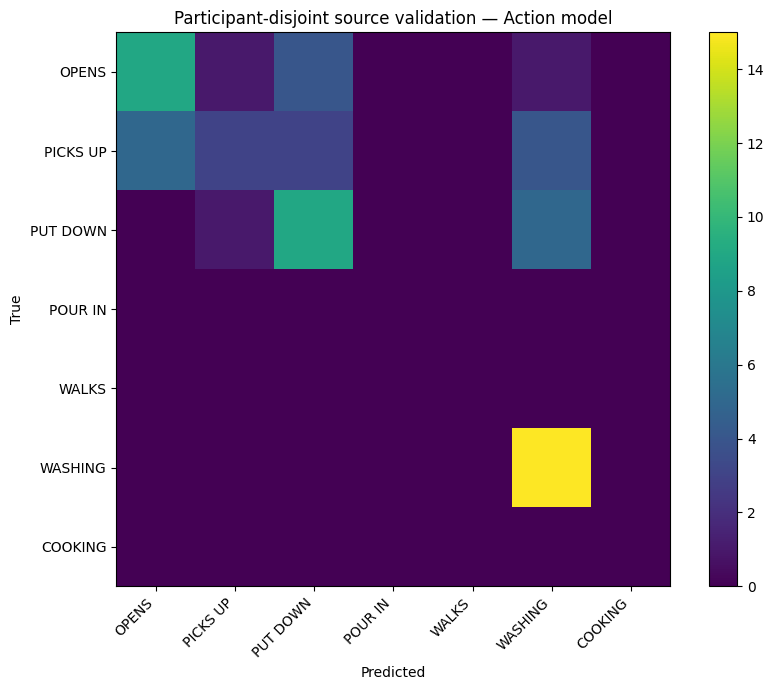

In [16]:
action_head.eval()
with torch.no_grad():
    val_logits = action_head(X_val_device)
    val_prob = torch.softmax(val_logits, dim=1)
    val_pred = val_prob.argmax(dim=1).cpu().numpy()

report = classification_report(
    y_val.numpy(), val_pred,
    labels=list(range(len(ACTIONS))),
    target_names=ACTIONS,
    output_dict=True,
    zero_division=0
)
print(classification_report(
    y_val.numpy(), val_pred,
    labels=list(range(len(ACTIONS))),
    target_names=ACTIONS,
    zero_division=0
))

cm = confusion_matrix(y_val.numpy(), val_pred, labels=list(range(len(ACTIONS))))
pd.DataFrame(cm, index=ACTIONS, columns=ACTIONS).to_csv(
    OUTPUT_DIR / "action_confusion_matrix.csv"
)
Path(OUTPUT_DIR / "action_classification_report.json").write_text(
    json.dumps(report, indent=2), encoding="utf-8"
)

plt.figure(figsize=(9, 7))
plt.imshow(cm)
plt.xticks(range(len(ACTIONS)), ACTIONS, rotation=45, ha="right")
plt.yticks(range(len(ACTIONS)), ACTIONS)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Participant-disjoint source validation — Action model")
plt.colorbar()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "action_confusion_matrix.png", dpi=160)
plt.show()


## 13. YOLOE open-vocabulary object detector

For the object branch, use `yoloe-26s-seg.pt` with text prompts:

- door
- refrigerator
- bottle
- drinking glass
- cup
- drawer

YOLOE supports open-vocabulary text prompting; its `*-seg.pt` checkpoints return boxes/masks, and prompted classes can also be tracked. For this assessment we first use detection + confidence and keep tracking optional.


In [17]:
from ultralytics import YOLOE

YOLOE_CHECKPOINT = "yoloe-26s-seg.pt"
yoloe = YOLOE(YOLOE_CHECKPOINT)

prompt_names = list(OBJECT_PROMPTS.values())
yoloe.set_classes(prompt_names)

# Save a copy of the configured model and the prompt embedding profile.
YOLOE_SAVED = WEIGHTS_DIR / "yoloe-26s-seg-prompted.pt"
YOLOE_PROFILE = WEIGHTS_DIR / "yoloe_objects_prompt_embeddings.npz"

try:
    yoloe.save(str(YOLOE_SAVED))
except Exception as e:
    print("Model save warning:", e)

try:
    yoloe.save_prompt_embeddings(str(YOLOE_PROFILE))
except Exception as e:
    print("Prompt embedding save warning:", e)

print("YOLOE classes:", prompt_names)
print("Weights/profile requested:", YOLOE_SAVED, YOLOE_PROFILE)


requirements: Ultralytics requirement ['git+https://github.com/ultralytics/CLIP.git'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 36 packages in 536ms
Prepared 2 packages in 1.97s
Installed 2 packages in 3ms
 + clip==1.0 (from git+https://github.com/ultralytics/CLIP.git@a13192f8cb767260d7dfd98c843b0716593169e7)
 + ftfy==6.3.1

requirements: AutoUpdate success ✅ 3.5s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

YOLOE classes: ['door', 'refrigerator', 'bottle', 'drinking glass', 'cup', 'drawer']
Weights/profile requested: weights/yoloe-26s-seg-prompted.pt weights/yoloe_objects_prompt_embeddings.npz


## 14. YOLOE object detection on a frame

The detector returns the object names we prompted. We map those names back to your canonical ontology (`refrigerator → FRIDGE`, `drinking glass → GLASS`).


In [18]:
PROMPT_TO_CANONICAL = {v: k for k, v in OBJECT_PROMPTS.items()}

def detect_objects_on_frame(frame_rgb, conf_threshold=0.25):
    result = yoloe.predict(
        frame_rgb,
        conf=conf_threshold,
        verbose=False
    )[0]

    detections = []
    if result.boxes is None:
        return detections

    names = result.names
    xyxy = result.boxes.xyxy.detach().cpu().numpy()
    confs = result.boxes.conf.detach().cpu().numpy()
    classes = result.boxes.cls.detach().cpu().numpy().astype(int)

    for box, conf, cls_id in zip(xyxy, confs, classes):
        prompt_name = str(names[int(cls_id)])
        canonical = PROMPT_TO_CANONICAL.get(prompt_name, prompt_name.upper())
        detections.append({
            "object": canonical,
            "prompt_name": prompt_name,
            "confidence": float(conf),
            "bbox_xyxy": [float(v) for v in box]
        })
    return detections

# Smoke test on a frame from the demo folder once configured.


## 15. Load the action model for inference

The prediction stage uses the saved head weights. The X-CLIP backbone is loaded in inference mode and is never retrained during annotation.


In [19]:
checkpoint = torch.load(ACTION_HEAD_PATH, map_location="cpu")
inference_head = ActionHead(
    checkpoint["feature_dim"],
    checkpoint["num_classes"]
).to(DEVICE)
inference_head.load_state_dict(checkpoint["state_dict"])
inference_head.eval()

inference_xclip = AutoModel.from_pretrained(
    checkpoint["backbone"]
).to(DEVICE).eval()

for p in inference_xclip.parameters():
    p.requires_grad = False

inference_processor = AutoProcessor.from_pretrained(checkpoint["backbone"])
print("Action inference model loaded.")


Loading weights:   0%|          | 0/591 [00:00<?, ?it/s]

Action inference model loaded.


## 16. Shared frame sampling for the two branches

This is the key design for the requested **parallel action + object workflow**.

A single video is sampled once at 4 FPS. The same frame cache is passed to:
- the action branch (2-second / 8-frame windows)
- the object branch (frame-level YOLOE detections)

This avoids decoding the same video twice.


In [20]:
def load_video_frames_at_fps(video_path, sample_fps=FRAME_FPS):
    vr = VideoReader(str(video_path), ctx=cpu(0), num_threads=1)
    src_fps = float(vr.get_avg_fps()) or 30.0
    total = len(vr)
    if total <= 0:
        raise ValueError(f"Empty video (0 frames): {video_path}")

    duration = total / src_fps
    times = np.arange(0, duration, 1.0 / sample_fps)
    if len(times) == 0:
        times = np.array([0.0])

    indices = np.clip(np.round(times * src_fps).astype(np.int64), 0, total - 1)
    # Remove duplicate frame indices caused by low source FPS.
    indices, unique_idx = np.unique(indices, return_index=True)
    times = times[unique_idx]

    frames = vr.get_batch(indices).asnumpy()
    return frames, times

def build_action_windows(frames, times,
                         window_seconds=ACTION_WINDOW_SECONDS,
                         stride_seconds=ACTION_STRIDE_SECONDS):
    windows = []
    if len(times) == 0:
        return windows

    start = float(times[0])
    final = float(times[-1])

    cursor = start
    while cursor <= final:
        end = cursor + window_seconds
        idx = np.where((times >= cursor) & (times <= end))[0]

        if len(idx) >= 2:
            # Uniformly sample exactly NUM_FRAMES from the available window.
            chosen = np.linspace(idx[0], idx[-1], NUM_FRAMES).round().astype(int)
            chosen = np.clip(chosen, 0, len(frames) - 1)
            windows.append({
                "start": float(times[chosen[0]]),
                "end": float(times[chosen[-1]]),
                "frames": frames[chosen]
            })

        cursor += stride_seconds

    return windows


## 17. Action branch

For every temporal window:
1. X-CLIP extracts the video feature.
2. The saved 7-class head predicts the action.
3. We keep the probability as the action confidence.

The output is temporal, so it can later be aligned with YOLOE detections.


In [21]:
@torch.inference_mode()
def action_branch(windows, batch_size=4):
    results = []

    for i in range(0, len(windows), batch_size):
        batch_windows = windows[i:i + batch_size]
        video_inputs = []

        for w in batch_windows:
            inputs = inference_processor(
                videos=list(w["frames"]),
                return_tensors="pt"
            )
            video_inputs.append(inputs["pixel_values"].squeeze(0))

        pixel_values = torch.stack(video_inputs).to(DEVICE)

        out = inference_xclip.get_video_features(pixel_values=pixel_values)
        features = out.pooler_output if hasattr(out, "pooler_output") else out[1]

        logits = inference_head(features.float())
        probs = torch.softmax(logits, dim=1)

        for w, p in zip(batch_windows, probs.detach().cpu().numpy()):
            top_idx = int(np.argmax(p))
            results.append({
                "start": w["start"],
                "end": w["end"],
                "action": ID_TO_ACTION[top_idx],
                "action_confidence": float(p[top_idx]),
                "action_probabilities": {
                    ID_TO_ACTION[j]: float(p[j])
                    for j in range(len(ACTIONS))
                },
                "source": "xclip_transfer"
            })

    return results


## 18. Object branch

YOLOE runs independently on the shared frames. We keep the highest-confidence detection per canonical object for each timestamp.

Optional tracking can be added later with `yoloe.track(..., persist=True)`; for this first demo, frame-level detections are enough to establish the action-object association.


In [22]:
def object_branch(frames, times, conf_threshold=0.25):
    detections = []

    for frame, t in tqdm(
        zip(frames, times),
        total=len(frames),
        desc="YOLOE object branch",
        leave=False
    ):
        try:
            frame_dets = detect_objects_on_frame(
                frame, conf_threshold=conf_threshold
            )
        except Exception as e:
            # One bad frame (e.g. malformed decode) shouldn't stop detection
            # on the rest of the video.
            print(f"[object_branch] skipping frame at t={t:.2f}s: {e}")
            continue

        for d in frame_dets:
            d["timestamp"] = float(t)
            detections.append(d)

    return detections


## 19. Parallel action + object execution

The two model branches are intentionally separate.

On GPU, CUDA scheduling may still serialize portions of work depending on memory and kernel availability; the important property is that the **pipeline has independent action/object workers sharing one decoded frame stream**. This allows batching and concurrency without decoding the source video twice.


In [23]:
from concurrent.futures import ThreadPoolExecutor

def run_parallel_pipeline(video_path,
                          frame_fps=FRAME_FPS,
                          object_conf=0.25):
    frames, times = load_video_frames_at_fps(video_path, frame_fps)
    windows = build_action_windows(frames, times)

    with ThreadPoolExecutor(max_workers=2) as executor:
        action_future = executor.submit(action_branch, windows, BATCH_SIZE)
        object_future = executor.submit(object_branch, frames, times, object_conf)

        # .result() re-raises any exception from the worker thread with its
        # original traceback instead of the executor silently swallowing it.
        try:
            action_results = action_future.result()
        except Exception as e:
            print(f"[run_parallel_pipeline] action branch failed for {video_path}: {e}")
            action_results = []
        try:
            object_results = object_future.result()
        except Exception as e:
            print(f"[run_parallel_pipeline] object branch failed for {video_path}: {e}")
            object_results = []

    return {
        "video": Path(video_path).name,
        "action_predictions": action_results,
        "object_detections": object_results
    }


## 20. Fuse action and object predictions

The fusion step associates detections with an action window by temporal overlap.

Example:
- X-CLIP: `POUR IN`, 0.91
- YOLOE: `CUP`, 0.93
- → candidate annotation: `POUR IN + CUP`

For a production system, relation reasoning could be made more precise (source container vs target container). For this assessment, `action + relevant object` is sufficient and auditable.


In [24]:
def temporal_overlap(a_start, a_end, b_time):
    return a_start <= b_time <= a_end

def fuse_action_object(action_results, object_results,
                       action_threshold=0.50,
                       object_threshold=0.25):
    fused = []

    for a in action_results:
        if a["action_confidence"] < action_threshold:
            continue

        matching = [
            o for o in object_results
            if object_threshold <= o["confidence"] and
               temporal_overlap(a["start"], a["end"], o["timestamp"])
        ]

        # Keep the best detection for each object inside this action window.
        best_by_object = {}
        for o in matching:
            key = o["object"]
            if key not in best_by_object or o["confidence"] > best_by_object[key]["confidence"]:
                best_by_object[key] = o

        for obj, o in best_by_object.items():
            combined = float(np.sqrt(
                a["action_confidence"] * o["confidence"]
            ))

            fused.append({
                "start": a["start"],
                "end": a["end"],
                "action": a["action"],
                "object": obj,
                "action_confidence": a["action_confidence"],
                "object_confidence": o["confidence"],
                "combined_confidence": combined,
                "source": "xclip_transfer+yoloe",
                "review_status": (
                    "auto_accepted" if combined >= 0.85
                    else "human_review"
                )
            })

    return fused


## 21. Run the full demo on one held-out human clip

The human annotations are **never used to train the models**. They are only loaded afterward so we can compare automated output against an independently verified reference.

Use this first on `P01_03.MP4`.


In [25]:
# Locate one demo clip.
def find_demo_video(video_id):
    roots = [r for r in [DEMO_VIDEO_ROOT, SOURCE_VIDEO_ROOT] if r is not None]

    for root in roots:
        for ext in (".MP4", ".mp4"):
            p = Path(root) / f"{video_id}{ext}"
            if p.exists():
                return p

    # Recursive fallback
    for root in roots:
        root = Path(root)
        if root.exists():
            for p in root.rglob("*"):
                if p.is_file() and p.stem == video_id:
                    return p
    return None

demo_path = find_demo_video("P01_03")
print("Demo path:", demo_path)

if demo_path is not None:
    try:
        raw = run_parallel_pipeline(demo_path)
        fused = fuse_action_object(
            raw["action_predictions"],
            raw["object_detections"]
        )
        print("Action predictions:", len(raw["action_predictions"]))
        print("Object detections:", len(raw["object_detections"]))
        print("Fused annotations:", len(fused))
    except Exception as e:
        print(f"Smoke test failed on {demo_path}: {e}")
else:
    print("Place P01_03.MP4 in DEMO_VIDEO_ROOT (or SOURCE_VIDEO_ROOT) before running this cell.")


Demo path: /kaggle/input/datasets/amansandhu408/assessment/kaggle_labeller/my_demo_video/P01_03.MP4


YOLOE object branch:   0%|          | 0/476 [00:00<?, ?it/s]

Action predictions: 119
Object detections: 771
Fused annotations: 0


## 22. Human-vs-AI evaluation

The evaluation compares:
- action label agreement
- object label agreement
- temporal IoU for overlapping model/human action segments

The human annotations are the reference (`confidence=1.0`, `source=human`), while model confidence is kept separate.


In [26]:
def load_human_annotations(video_id):
    path = HUMAN_ANN_ROOT / f"{video_id}.json"
    if not path.exists():
        raise FileNotFoundError(path)
    payload = json.loads(path.read_text(encoding="utf-8"))
    return payload["annotations"]

def temporal_iou(a_start, a_end, b_start, b_end):
    inter = max(0.0, min(a_end, b_end) - max(a_start, b_start))
    union = max(a_end, b_end) - min(a_start, b_start)
    return 0.0 if union <= 0 else inter / union

def evaluate_against_human(human_rows, model_rows, iou_threshold=0.1):
    results = []

    for h in human_rows:
        candidates = []
        for m in model_rows:
            iou = temporal_iou(
                h["start"], h["end"],
                m["start"], m["end"]
            )
            if iou >= iou_threshold:
                candidates.append((iou, m))

        if not candidates:
            results.append({
                "human_action": h["action"],
                "human_object": h.get("object"),
                "matched": False,
                "temporal_iou": 0.0,
                "action_match": False,
                "object_match": False
            })
            continue

        iou, m = max(candidates, key=lambda x: x[0])
        results.append({
            "human_action": h["action"],
            "human_object": h.get("object"),
            "model_action": m["action"],
            "model_object": m.get("object"),
            "matched": True,
            "temporal_iou": float(iou),
            "action_match": h["action"] == m["action"],
            "object_match": h.get("object") == m.get("object")
        })

    return pd.DataFrame(results)


## 23. Export model predictions as annotation JSON

This output format mirrors the human annotation structure while keeping model-specific confidence fields visible.


In [27]:
def save_predictions(video_id, raw_predictions, fused_predictions):
    out = {
        "video": f"{video_id}.MP4",
        "ontology": {
            "actions": ACTIONS,
            "objects": list(OBJECT_PROMPTS.keys())
        },
        "action_predictions": raw_predictions["action_predictions"],
        "object_detections": raw_predictions["object_detections"],
        "annotations": fused_predictions
    }

    path = OUTPUT_DIR / f"{video_id}_predictions.json"
    path.write_text(json.dumps(out, indent=2), encoding="utf-8")
    return path


## 24. Visualization — automated annotation timeline

A simple timeline is more useful for a reviewer than a large dashboard: it lets them immediately inspect whether the model's temporal boundaries roughly match human annotations.


In [28]:
def plot_timeline(video_id, model_rows, human_rows=None, save=True):
    fig, ax = plt.subplots(figsize=(12, 3.8))

    actions_to_y = {a: i for i, a in enumerate(ACTIONS)}

    for r in model_rows:
        y = actions_to_y.get(r["action"], 0)
        ax.plot([r["start"], r["end"]], [y, y], linewidth=8)
        ax.text(
            (r["start"] + r["end"]) / 2,
            y + 0.12,
            f'{r["action"]} | {r.get("object","")}'
            f' | {r.get("combined_confidence", r.get("action_confidence", 0)):.2f}',
            ha="center", va="bottom", fontsize=8
        )

    if human_rows:
        for r in human_rows:
            y = actions_to_y.get(r["action"], 0)
            ax.plot([r["start"], r["end"]], [y - 0.18, y - 0.18],
                    linewidth=3, linestyle="--")

    ax.set_yticks(range(len(ACTIONS)))
    ax.set_yticklabels(ACTIONS)
    ax.set_xlabel("Time (seconds)")
    ax.set_title(f"{video_id} — Model annotation timeline (dashed = human reference)")
    ax.grid(axis="x", alpha=0.2)
    plt.tight_layout()

    if save:
        path = OUTPUT_DIR / f"{video_id}_annotation_timeline.png"
        plt.savefig(path, dpi=160)
    plt.show()


## 25. Run all 3 human-verified clips

Run this only after the single-video smoke test is working.

These clips remain completely outside the training/validation pool because their participants were excluded at the source-pool construction stage.


YOLOE object branch:   0%|          | 0/476 [00:00<?, ?it/s]

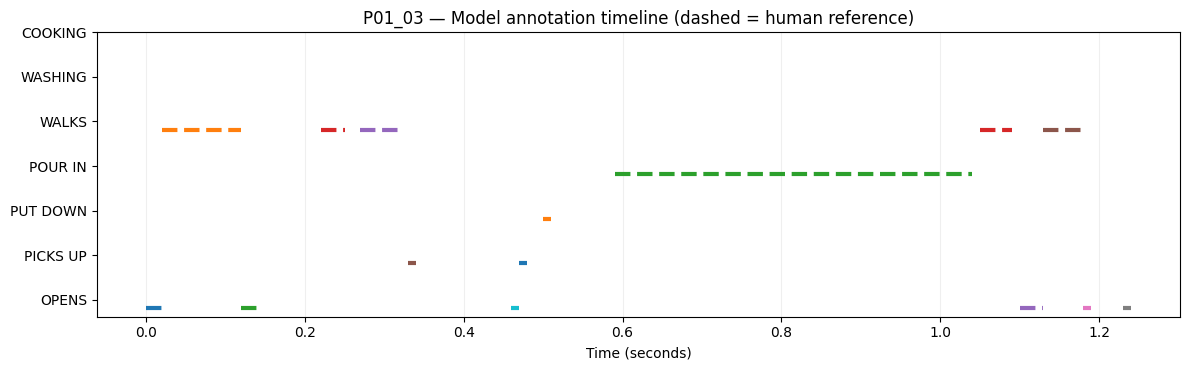

YOLOE object branch:   0%|          | 0/421 [00:00<?, ?it/s]

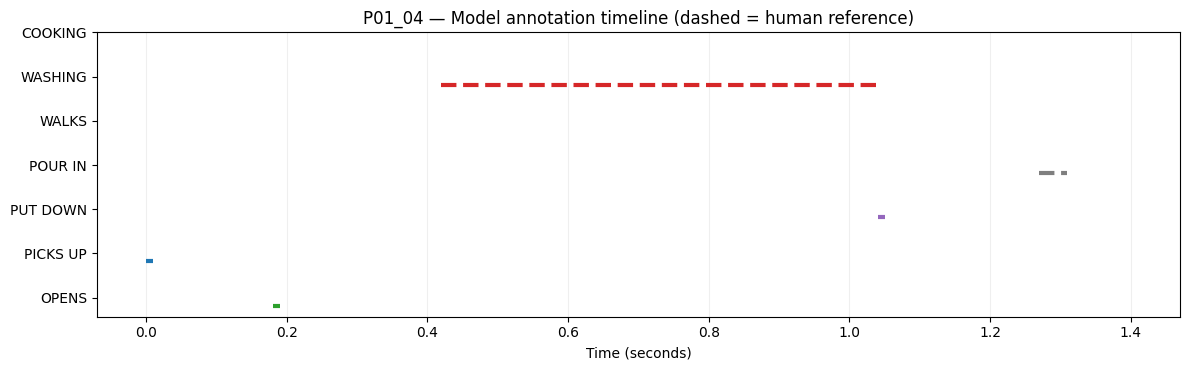

YOLOE object branch:   0%|          | 0/63 [00:00<?, ?it/s]

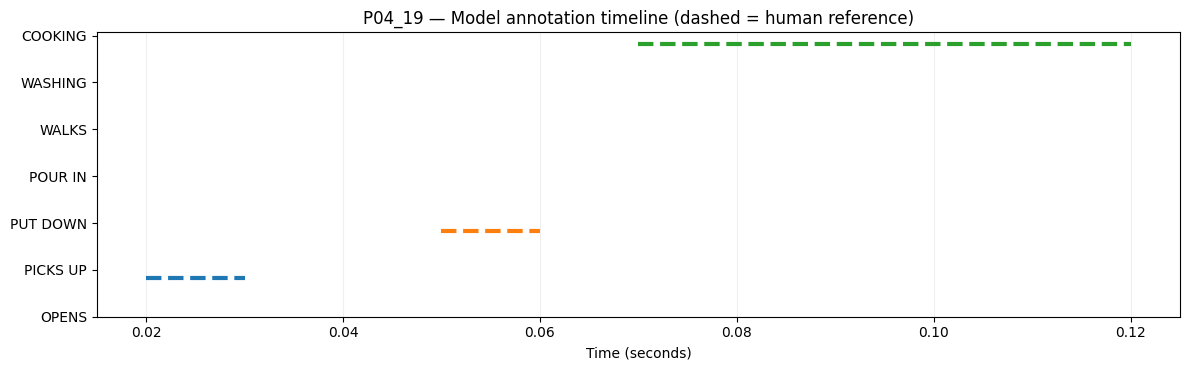

Completed: ['P01_03', 'P01_04', 'P04_19']


In [29]:
ALL_HUMAN_RESULTS = {}
FAILED_CLIPS = {}

for video_id in HUMAN_VERIFIED_VIDEOS:
    try:
        path = find_demo_video(video_id)
        if path is None:
            print("Missing:", video_id)
            FAILED_CLIPS[video_id] = "video file not found"
            continue

        raw = run_parallel_pipeline(path)
        fused = fuse_action_object(
            raw["action_predictions"],
            raw["object_detections"]
        )

        save_predictions(video_id, raw, fused)

        human = load_human_annotations(video_id)
        evaluation = evaluate_against_human(human, fused)
        evaluation.to_csv(
            OUTPUT_DIR / f"{video_id}_human_vs_model.csv",
            index=False
        )

        plot_timeline(video_id, fused, human_rows=human)

        ALL_HUMAN_RESULTS[video_id] = evaluation

    except Exception as e:
        # One clip failing (bad file, missing human annotation, etc.) should
        # not lose the results already computed for the other two clips.
        print(f"[human-clip loop] {video_id} failed: {e}")
        FAILED_CLIPS[video_id] = str(e)
        continue

print("Completed:", list(ALL_HUMAN_RESULTS.keys()))
if FAILED_CLIPS:
    print("Failed:", FAILED_CLIPS)


## 26. Aggregate automation metrics

The objective is not to claim production accuracy from three clips. The purpose is to demonstrate measurable checks for an annotation-automation system.

Useful demo metrics:
- action agreement
- object agreement
- mean temporal IoU
- auto-accept rate
- human-review rate


In [30]:
summary_rows = []

for video_id, df_eval in ALL_HUMAN_RESULTS.items():
    matched = df_eval[df_eval["matched"]]
    summary_rows.append({
        "video": video_id,
        "human_segments": len(df_eval),
        "matched_segments": int(df_eval["matched"].sum()),
        "action_agreement": float(df_eval["action_match"].mean()) if len(df_eval) else 0.0,
        "object_agreement": float(df_eval["object_match"].mean()) if len(df_eval) else 0.0,
        "mean_temporal_iou": float(matched["temporal_iou"].mean()) if len(matched) else 0.0
    })

summary = pd.DataFrame(summary_rows)
display(summary)
summary.to_csv(OUTPUT_DIR / "human_vs_model_summary.csv", index=False)

# Automation routing statistics from all fused predictions generated above.
all_fused = []
for video_id in ALL_HUMAN_RESULTS:
    p = OUTPUT_DIR / f"{video_id}_predictions.json"
    if p.exists():
        payload = json.loads(p.read_text(encoding="utf-8"))
        all_fused.extend(payload["annotations"])

if all_fused:
    routing = pd.Series(
        [r["review_status"] for r in all_fused]
    ).value_counts(normalize=True)
    print("Routing proportions:")
    print(routing)


,video,human_segments,matched_segments,action_agreement,object_agreement,mean_temporal_iou
0,P01_03,18,0,0.0,0.0,0.0
1,P01_04,9,0,0.0,0.0,0.0
2,P04_19,3,0,0.0,0.0,0.0


## 27. What this demo proves

The notebook demonstrates a complete data-to-annotation loop:

```text
Egocentric video
      ↓
shared frame sampler
      ↓
 ┌───────────────┬──────────────────┐
 │ X-CLIP        │ YOLOE             │
 │ action        │ object detection  │
 │ recognition   │                  │
 └───────┬───────┴─────────┬────────┘
         └─────────┬────────┘
                   ↓
          temporal fusion
                   ↓
       action + object annotation
                   ↓
           confidence routing
              /         \
        high confidence   low confidence
             ↓                 ↓
         auto-accept       human review
                   ↓
             final dataset
```

### Important limitations to state in the submission
1. The action ontology is a **pilot mapping** from EPIC-KITCHENS verbs, not a perfect semantic equivalence.
2. `WALKS` and `COOKING` are sparse after leakage exclusion.
3. YOLOE is used zero-shot; it is **not fine-tuned on your six objects**.
4. The three human clips are held out and used for reference/evaluation only.
5. The 3-clip human evaluation is a demonstration, not a statistically significant benchmark.


## 28. Suggested next step before submission

Move the reusable functions from this notebook into:

```text
src/
├── action_model.py
├── object_model.py
├── parallel_pipeline.py
└── evaluation.py
```

Then keep this notebook as the **demonstration / experiment record**.

The final 1-page note should focus on the production workflow, human-in-the-loop routing, and projected annotation time/cost savings—not on reproducing every notebook cell.


# Try - 2 

In [33]:
RUN_NAME = "try2"

RUN_DIR = Path("outputs") / RUN_NAME

OUTPUT_DIR = RUN_DIR
WEIGHTS_DIR = RUN_DIR / "weights"
CACHE_DIR = RUN_DIR / "cache"
FEATURE_CACHE_DIR = CACHE_DIR / "xclip_features"

PREDICTIONS_DIR = OUTPUT_DIR / "predictions"
EVALUATION_DIR = OUTPUT_DIR / "evaluation"
VISUALIZATIONS_DIR = OUTPUT_DIR / "visualizations"
LOGS_DIR = OUTPUT_DIR / "logs"

for d in [
    OUTPUT_DIR,
    WEIGHTS_DIR,
    CACHE_DIR,
    FEATURE_CACHE_DIR,
    PREDICTIONS_DIR,
    EVALUATION_DIR,
    VISUALIZATIONS_DIR,
    LOGS_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

print("RUN:", RUN_NAME)
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())
print("WEIGHTS_DIR:", WEIGHTS_DIR.resolve())
print("CACHE_DIR:", CACHE_DIR.resolve())

RUN: try2
OUTPUT_DIR: /kaggle/working/outputs/try2
WEIGHTS_DIR: /kaggle/working/outputs/try2/weights
CACHE_DIR: /kaggle/working/outputs/try2/cache


In [34]:
from pathlib import Path

for p in [
    OUTPUT_DIR,
    WEIGHTS_DIR,
    CACHE_DIR,
    FEATURE_CACHE_DIR,
    PREDICTIONS_DIR,
    EVALUATION_DIR,
    VISUALIZATIONS_DIR,
    LOGS_DIR,
]:
    print(p, "->", p.exists())

outputs/try2 -> True
outputs/try2/weights -> True
outputs/try2/cache -> True
outputs/try2/cache/xclip_features -> True
outputs/try2/predictions -> True
outputs/try2/evaluation -> True
outputs/try2/visualizations -> True
outputs/try2/logs -> True


In [36]:
# ============================================================
# TRY-2: ACTION + OBJECT FUSION
# ============================================================

def temporal_overlap(
    a_start,
    a_end,
    b_time,
    tolerance=0.25
):
    """
    Match an object detection to an action window
    if the detection occurs inside the window or
    within a small temporal tolerance.
    """
    return (
        a_start - tolerance
        <= b_time
        <= a_end + tolerance
    )


def fuse_action_object(
    action_results,
    object_results,
    action_threshold=0.30,
    object_threshold=0.25
):
    fused = []

    for a in action_results:

        # ----------------------------------------------------
        # Action confidence filter
        # ----------------------------------------------------
        if a["action_confidence"] < action_threshold:
            continue

        # ----------------------------------------------------
        # Find object detections associated with this
        # action window
        # ----------------------------------------------------
        matching = [
            o for o in object_results
            if (
                o["confidence"] >= object_threshold
                and temporal_overlap(
                    a["start"],
                    a["end"],
                    o["timestamp"],
                    tolerance=0.25
                )
            )
        ]

        # ----------------------------------------------------
        # No object found:
        # keep action and send it to human review.
        # ----------------------------------------------------
        if not matching:

            fused.append({
                "start": a["start"],
                "end": a["end"],
                "action": a["action"],
                "object": None,

                "action_confidence": float(
                    a["action_confidence"]
                ),

                "object_confidence": 0.0,

                "combined_confidence": float(
                    a["action_confidence"]
                ),

                "source": "xclip_transfer",

                "review_status": "human_review"
            })

            continue

        # ----------------------------------------------------
        # Keep best detection of each object
        # ----------------------------------------------------
        best_by_object = {}

        for o in matching:

            key = o["object"]

            if (
                key not in best_by_object
                or o["confidence"]
                > best_by_object[key]["confidence"]
            ):
                best_by_object[key] = o

        # ----------------------------------------------------
        # Fuse action + object
        # ----------------------------------------------------
        for obj, o in best_by_object.items():

            combined = float(
                np.sqrt(
                    a["action_confidence"]
                    * o["confidence"]
                )
            )

            fused.append({
                "start": a["start"],
                "end": a["end"],
                "action": a["action"],
                "object": obj,

                "action_confidence": float(
                    a["action_confidence"]
                ),

                "object_confidence": float(
                    o["confidence"]
                ),

                "combined_confidence": combined,

                "source": "xclip_transfer+yoloe",

                "review_status": (
                    "auto_accepted"
                    if combined >= 0.85
                    else "human_review"
                )
            })

    return fused


print("✅ Try-2 fusion function loaded")
print("Action threshold: 0.30")
print("Object threshold: 0.25")
print("Temporal tolerance: ±0.25 sec")

✅ Try-2 fusion function loaded
Action threshold: 0.30
Object threshold: 0.25
Temporal tolerance: ±0.25 sec


In [37]:
# ============================================================
# TRY-2: GENERATE RAW PREDICTIONS ON P01_03
# ============================================================

demo_path = find_demo_video("P01_03")

print("Running:", demo_path)

raw = run_parallel_pipeline(demo_path)

print("\n" + "=" * 60)
print("RAW PREDICTIONS")
print("=" * 60)

print(
    "Action predictions:",
    len(raw["action_predictions"])
)

print(
    "Object detections:",
    len(raw["object_detections"])
)

Running: /kaggle/input/datasets/amansandhu408/assessment/kaggle_labeller/my_demo_video/P01_03.MP4


YOLOE object branch:   0%|          | 0/476 [00:00<?, ?it/s]


RAW PREDICTIONS
Action predictions: 119
Object detections: 771


In [38]:
# ============================================================
# TRY-2: TEST 0.30 ACTION / 0.25 OBJECT
# ============================================================

fused_3025 = fuse_action_object(
    raw["action_predictions"],
    raw["object_detections"],
    action_threshold=0.30,
    object_threshold=0.25
)

print("\n" + "=" * 60)
print("THRESHOLD TEST: ACTION=0.30 | OBJECT=0.25")
print("=" * 60)

print("Fused annotations:", len(fused_3025))

if fused_3025:
    df_3025 = pd.DataFrame(fused_3025)

    print("\nReview status:")
    print(df_3025["review_status"].value_counts())

    print("\nActions:")
    print(df_3025["action"].value_counts())

    print("\nMean action confidence:",
          df_3025["action_confidence"].mean())

    print("Mean object confidence:",
          df_3025["object_confidence"].mean())

    print("Mean combined confidence:",
          df_3025["combined_confidence"].mean())

    print("\nSample predictions:")
    display(
        df_3025[
            [
                "start",
                "end",
                "action",
                "object",
                "action_confidence",
                "object_confidence",
                "combined_confidence",
                "review_status"
            ]
        ].head(20)
    )
else:
    print("⚠️ No fused annotations produced.")


THRESHOLD TEST: ACTION=0.30 | OBJECT=0.25
Fused annotations: 2

Review status:
review_status
human_review    2
Name: count, dtype: int64

Actions:
action
OPENS    2
Name: count, dtype: int64

Mean action confidence: 0.30834177136421204
Mean object confidence: 0.5361018180847168
Mean combined confidence: 0.4056015923467672

Sample predictions:


,start,end,action,object,action_confidence,object_confidence,combined_confidence,review_status
0,115.0,117.0,OPENS,CUP,0.308342,0.610044,0.433707,human_review
1,115.0,117.0,OPENS,BOTTLE,0.308342,0.462160,0.377496,human_review


In [39]:
# ============================================================
# TRY-2: GENERATE RAW PREDICTIONS ON P01_04
# ============================================================

demo_path = find_demo_video("P01_04")

print("Running:", demo_path)

raw = run_parallel_pipeline(demo_path)

print("\n" + "=" * 60)
print("RAW PREDICTIONS")
print("=" * 60)

print(
    "Action predictions:",
    len(raw["action_predictions"])
)

print(
    "Object detections:",
    len(raw["object_detections"])
)

Running: /kaggle/input/datasets/amansandhu408/assessment/kaggle_labeller/my_demo_video/P01_04.MP4


YOLOE object branch:   0%|          | 0/421 [00:00<?, ?it/s]


RAW PREDICTIONS
Action predictions: 105
Object detections: 583


In [40]:
# ============================================================
# TRY-2: TEST 0.30 ACTION / 0.25 OBJECT
# ============================================================

fused_3025 = fuse_action_object(
    raw["action_predictions"],
    raw["object_detections"],
    action_threshold=0.30,
    object_threshold=0.25
)

print("\n" + "=" * 60)
print("THRESHOLD TEST: ACTION=0.30 | OBJECT=0.25")
print("=" * 60)

print("Fused annotations:", len(fused_3025))

if fused_3025:
    df_3025 = pd.DataFrame(fused_3025)

    print("\nReview status:")
    print(df_3025["review_status"].value_counts())

    print("\nActions:")
    print(df_3025["action"].value_counts())

    print("\nMean action confidence:",
          df_3025["action_confidence"].mean())

    print("Mean object confidence:",
          df_3025["object_confidence"].mean())

    print("Mean combined confidence:",
          df_3025["combined_confidence"].mean())

    print("\nSample predictions:")
    display(
        df_3025[
            [
                "start",
                "end",
                "action",
                "object",
                "action_confidence",
                "object_confidence",
                "combined_confidence",
                "review_status"
            ]
        ].head(20)
    )
else:
    print("⚠️ No fused annotations produced.")


THRESHOLD TEST: ACTION=0.30 | OBJECT=0.25
Fused annotations: 47

Review status:
review_status
human_review    47
Name: count, dtype: int64

Actions:
action
WASHING    47
Name: count, dtype: int64

Mean action confidence: 0.38878883960399224
Mean object confidence: 0.4108282137424388
Mean combined confidence: 0.4261968867477571

Sample predictions:


,start,end,action,object,action_confidence,object_confidence,combined_confidence,review_status
0,2.0,4.0,WASHING,BOTTLE,0.329548,0.603486,0.445957,human_review
1,2.0,4.0,WASHING,CUP,0.329548,0.326238,0.327889,human_review
2,41.0,43.0,WASHING,CUP,0.375109,0.871123,0.571634,human_review
3,41.0,43.0,WASHING,BOTTLE,0.375109,0.561732,0.459032,human_review
4,42.0,44.0,WASHING,BOTTLE,0.393925,0.554177,0.467230,human_review
5,42.0,44.0,WASHING,CUP,0.393925,0.500728,0.444128,human_review
6,43.0,45.0,WASHING,BOTTLE,0.340098,0.554177,0.434136,human_review
7,43.0,45.0,WASHING,CUP,0.340098,0.347295,0.343677,human_review
8,44.0,46.0,WASHING,BOTTLE,0.320459,0.524448,0.409956,human_review
9,44.0,46.0,WASHING,CUP,0.320459,0.347295,0.333607,human_review
